In [21]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [22]:
import pandas as pd
import xgboost as xgb
import seaborn as sns

print("全部OK ✅")

全部OK ✅


In [23]:
# 2. load csv
url = "https://raw.githubusercontent.com/PeiyaoPearl/CASA0006-Data-Science-for-Spatial-Systems-/refs/heads/main/Assessments/data/Ltds_clean.csv" 
df= pd.read_csv(url)
current_rows = len(df)
print(f"📊 当前加载的记录数: {current_rows}，包含 {len(df.columns)} 个变量。")

# Count the number of records each year
year_counts = df['year'].value_counts().sort_index()

print("📅 各年度行程记录总数：")
print(year_counts)

# 如果你想看占比（百分比）
year_percentage = df['year'].value_counts(normalize=True).sort_index() * 100
print("\n📊 各年度占比 (%)：")
print(year_percentage.round(2))


📊 当前加载的记录数: 220183，包含 18 个变量。
📅 各年度行程记录总数：
year
2014    36327
2015    39066
2016    36663
2017    35375
2018    35626
2019    37126
Name: count, dtype: int64

📊 各年度占比 (%)：
year
2014   16.50
2015   17.74
2016   16.65
2017   16.07
2018   16.18
2019   16.86
Name: proportion, dtype: float64


In [24]:
df.head()


,unique_trip_id,year,mode,distance_(km),journey_purpose,trip_start_time_period,origin_borough,gender,age,car_access,working_status,household_income,disability,ethnicity,household_structure,borough_mean_ptal,borough_pop_density,road_density
0,190010210101,2019,walk,1.07,shopping and personal business,am peak (0700-0959),barking & dagenham,female,32,no car,not working,10000 - 14999,not disabled,"mixed, other and arab",single pensioner,8.42,6530.50,9.59
1,190010210102,2019,walk,1.07,shopping and personal business,interpeak (1000-1559),barking & dagenham,female,32,no car,not working,10000 - 14999,not disabled,"mixed, other and arab",single pensioner,8.42,6530.50,9.59
2,190010510301,2019,pt,15.19,usual workplace,am peak (0700-0959),barking & dagenham,male,35,two or more car,full-time worker,75000 - 99999,not disabled,asian,couple without children,8.42,6530.50,9.59
3,190010510302,2019,pt,15.19,usual workplace,evening (1900-2159),islington,male,35,two or more car,full-time worker,75000 - 99999,not disabled,asian,couple without children,25.40,15129.70,15.94
4,190010710101,2019,pt,15.91,education,am peak (0700-0959),barking & dagenham,male,55,one car,part-time worker,5000 - 9999,not disabled,asian,lone parent,8.42,6530.50,9.59


In [25]:
# 查看全表每一列的 NaN 数量
nan_counts = df.isnull().sum()

# 查看全表缺失值占比 (%)
nan_percentage = (df.isnull().sum() / len(df)) * 100

# 专门查看 household_income 列
income_nan = df['household_income'].isnull().sum()

print("--- 缺失值统计 (Total NaN Counts) ---")
print(nan_counts)
print("\n--- 缺失值占比 (Percentage %) ---")
print(nan_percentage)
print(f"\n⚠️ household_income 列共有 {income_nan} 个 NaN 值。")

--- 缺失值统计 (Total NaN Counts) ---
unique_trip_id            0
year                      0
mode                      0
distance_(km)             0
journey_purpose           0
trip_start_time_period    0
origin_borough            0
gender                    0
age                       0
car_access                0
working_status            0
household_income          0
disability                0
ethnicity                 0
household_structure       0
borough_mean_ptal         0
borough_pop_density       0
road_density              0
dtype: int64

--- 缺失值占比 (Percentage %) ---
unique_trip_id           0.00
year                     0.00
mode                     0.00
distance_(km)            0.00
journey_purpose          0.00
trip_start_time_period   0.00
origin_borough           0.00
gender                   0.00
age                      0.00
car_access               0.00
working_status           0.00
household_income         0.00
disability               0.00
ethnicity                0.00


In [26]:
import pandas as pd
import numpy as np

# 1. 如果该列现在全是 nan，我们需要确保它是字符串类型
# 如果你发现 df['household_income'] 已经彻底丢失数据，请确保之前的加载代码没有 dropna() 掉它
df['household_income'] = df['household_income'].astype(str)

# 2. 定义一个灵活的清洗函数，处理各种符号和空格
def clean_income(val):
    s = str(val).replace('£', '').replace(',', '').strip().lower()
    if 'nan' in s or 'unknown' in s or s == '':
        return 'Unknown'
    
    # 根据关键词映射到你的 10 个分类
    if '100000' in s: return '>100000'
    if '75000' in s: return '75000-99999'
    if '50000' in s: return '50000-74999'
    if '35000' in s: return '35000-49999'
    if '25000' in s: return '25000-34999'
    if '20000' in s: return '20000-24999'
    if '15000' in s: return '15000-19999'
    if '10000' in s: return '10000-14999'
    if '5000' in s: return '5000-9999'
    if 'less than' in s or '0 - 4' in s or 'under' in s: return '<5000'
    
    return 'Unknown'

# 执行清洗映射
df['household_income'] = df['household_income'].apply(clean_income)

# 3. 重新设置为有序分类
income_order_final = ['<5000', '5000-9999', '10000-14999', '15000-19999', 
                      '20000-24999', '25000-34999', '35000-49999', 
                      '50000-74999', '75000-99999', '>100000', 'Unknown']

df['household_income'] = pd.Categorical(df['household_income'], 
                                        categories=income_order_final, 
                                        ordered=True)

# 检查结果：如果这里全是 0，说明原始数据源确实没加载进来
print("清洗后的分布情况：")
print(df['household_income'].value_counts())

清洗后的分布情况：
household_income
50000-74999    35174
>100000        33091
35000-49999    32985
25000-34999    25936
5000-9999      22663
75000-99999    20724
10000-14999    16917
20000-24999    16540
15000-19999    16153
<5000              0
Unknown            0
Name: count, dtype: int64


EDA

/var/folders/2f/9fqrm6p16sxbkj608dl5djbm0000gn/T/ipykernel_44553/2194295035.py:10: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['household_income'] = pd.Categorical(df['household_income'], categories=income_order, ordered=True)


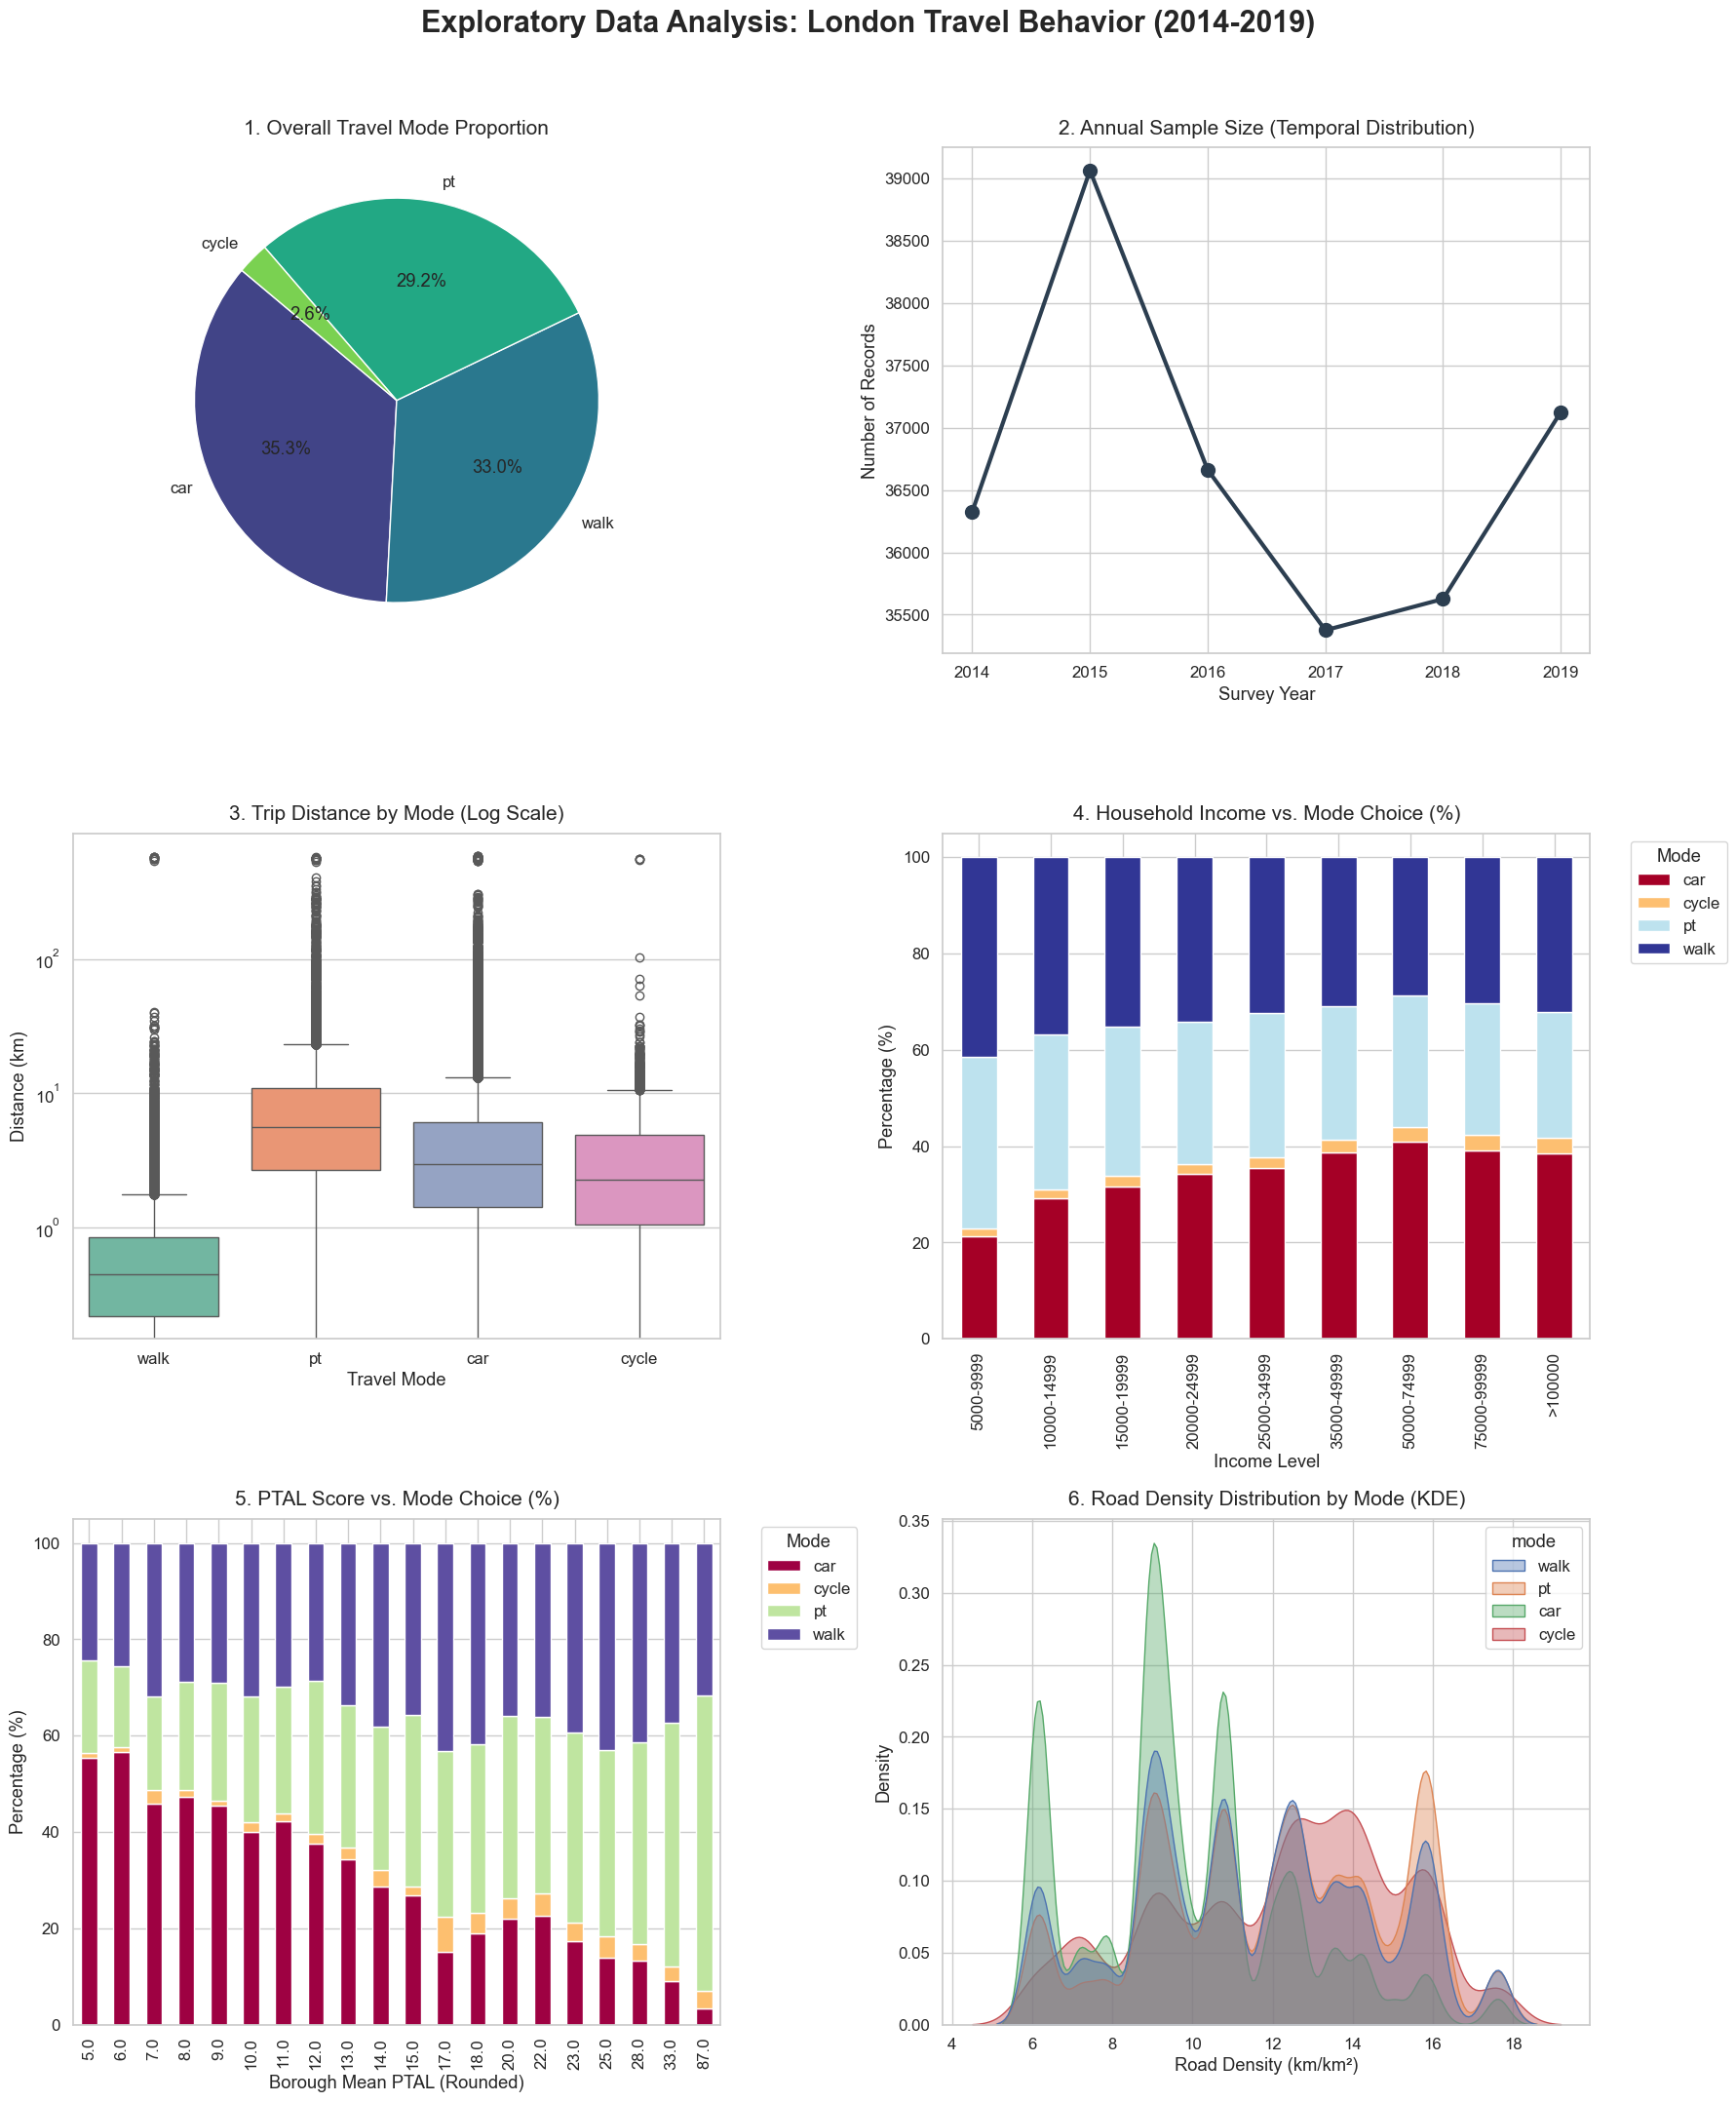

In [27]:

# 1. 风格与基础配置
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'

# 2. 确保收入分类顺序正确 (根据你刚才清洗出的 labels)
income_order = ['5000-9999', '10000-14999', '15000-19999', '20000-24999', 
                '25000-34999', '35000-49999', '50000-74999', '75000-99999', '>100000']

# 过滤掉 count 为 0 的 '<5000' 和 'Unknown'
df['household_income'] = pd.Categorical(df['household_income'], categories=income_order, ordered=True)

# ---------------------------------------------------------
# 创建画布：3行2列
fig, axes = plt.subplots(3, 2, figsize=(18, 22))
fig.suptitle('Exploratory Data Analysis: London Travel Behavior (2014-2019)', fontsize=22, fontweight='bold', y=0.98)

# --- 1. 位置 (0,0): Travel Mode Proportion (饼图) ---
mode_counts = df['mode'].value_counts()
axes[0, 0].pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%', 
               startangle=140, colors=sns.color_palette("viridis", len(mode_counts)),
               wedgeprops={'edgecolor': 'white'})
axes[0, 0].set_title('1. Overall Travel Mode Proportion', fontsize=15, pad=10)

# --- 2. 位置 (0,1): Annual Sample Size (折线图) ---
year_counts = df['year'].value_counts().sort_index()
axes[0, 1].plot(year_counts.index.astype(str), year_counts.values, marker='o', linewidth=3, markersize=10, color='#2c3e50')
axes[0, 1].set_title('2. Annual Sample Size (Temporal Distribution)', fontsize=15, pad=10)
axes[0, 1].set_xlabel('Survey Year')
axes[0, 1].set_ylabel('Number of Records')

# --- 3. 位置 (1,0): Trip Distance by Mode (箱线图) ---
sns.boxplot(data=df, x='mode', y='distance_(km)', ax=axes[1, 0], palette='Set2', hue='mode', legend=False)
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('3. Trip Distance by Mode (Log Scale)', fontsize=15, pad=10)
axes[1, 0].set_xlabel('Travel Mode')
axes[1, 0].set_ylabel('Distance (km)')

# --- 4. 位置 (1,1): Household Income vs. Mode (堆叠柱状图) ---
# 此时数据已经清洗好，直接做 crosstab
income_cross = pd.crosstab(df['household_income'], df['mode'], normalize='index') * 100
if not income_cross.empty:
    income_cross.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='RdYlBu', edgecolor='white')
    axes[1, 1].set_title('4. Household Income vs. Mode Choice (%)', fontsize=15, pad=10)
    axes[1, 1].set_xlabel('Income Level')
    axes[1, 1].set_ylabel('Percentage (%)')
    axes[1, 1].legend(title='Mode', bbox_to_anchor=(1.05, 1), loc='upper left')

# --- 5. 位置 (2,0): PTAL Score vs. Mode (堆叠柱状图) ---
if 'borough_mean_ptal' in df.columns:
    ptal_cross = pd.crosstab(df['borough_mean_ptal'].round(), df['mode'], normalize='index') * 100
    ptal_cross.plot(kind='bar', stacked=True, ax=axes[2, 0], colormap='Spectral', edgecolor='white')
    axes[2, 0].set_title('5. PTAL Score vs. Mode Choice (%)', fontsize=15, pad=10)
    axes[2, 0].set_xlabel('Borough Mean PTAL (Rounded)')
    axes[2, 0].set_ylabel('Percentage (%)')
    axes[2, 0].legend(title='Mode', bbox_to_anchor=(1.05, 1), loc='upper left')

# --- 6. 位置 (2,1): Road Density Distribution (KDE 图) ---
if 'road_density' in df.columns:
    sns.kdeplot(data=df, x='road_density', hue='mode', fill=True, common_norm=False, ax=axes[2, 1], alpha=0.4)
    axes[2, 1].set_title('6. Road Density Distribution by Mode (KDE)', fontsize=15, pad=10)
    axes[2, 1].set_xlabel('Road Density (km/km²)')

# 自动调整子图间距，防止标签重叠
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [28]:
df.head()



,unique_trip_id,year,mode,distance_(km),journey_purpose,trip_start_time_period,origin_borough,gender,age,car_access,working_status,household_income,disability,ethnicity,household_structure,borough_mean_ptal,borough_pop_density,road_density
0,190010210101,2019,walk,1.07,shopping and personal business,am peak (0700-0959),barking & dagenham,female,32,no car,not working,10000-14999,not disabled,"mixed, other and arab",single pensioner,8.42,6530.50,9.59
1,190010210102,2019,walk,1.07,shopping and personal business,interpeak (1000-1559),barking & dagenham,female,32,no car,not working,10000-14999,not disabled,"mixed, other and arab",single pensioner,8.42,6530.50,9.59
2,190010510301,2019,pt,15.19,usual workplace,am peak (0700-0959),barking & dagenham,male,35,two or more car,full-time worker,75000-99999,not disabled,asian,couple without children,8.42,6530.50,9.59
3,190010510302,2019,pt,15.19,usual workplace,evening (1900-2159),islington,male,35,two or more car,full-time worker,75000-99999,not disabled,asian,couple without children,25.40,15129.70,15.94
4,190010710101,2019,pt,15.91,education,am peak (0700-0959),barking & dagenham,male,55,one car,part-time worker,5000-9999,not disabled,asian,lone parent,8.42,6530.50,9.59


In [29]:

# Set display resolution
pd.set_option('display.float_format', lambda x: '%.2f' % x)

def generate_academic_table(df):
    results = []

    # --- A. Dependent Variable (mode) ---
    results.append({'Variable': 'Dependent variable', 'Proportion/Mean': '', 'SD': ''})
    counts = df['mode'].value_counts(normalize=True) * 100
    for category, prop in counts.items():
        results.append({'Variable': f'  {category} (%)', 'Proportion/Mean': prop, 'SD': '-'})

    # --- B. Independent Variables (Numerical) ---
    results.append({'Variable': 'Independent variables (Numerical)', 'Proportion/Mean': '', 'SD': ''})
    num_features = {
        'distance_(km)': 'Trip distance (km)',
        'age': 'Age (years)',
        'borough_mean_ptal': 'PTAL Score',
        'road_density': 'Road density (km/km²)'
    }
    
    for col, label in num_features.items():
        if col in df.columns:
            mean_val = df[col].mean()
            sd_val = df[col].std()
            results.append({'Variable': f'  {label}', 'Proportion/Mean': mean_val, 'SD': sd_val})

    # --- C. Independent Variables (Categorical) ---
    cat_features = {
        'gender': 'Gender (%)',
        'household_income': 'Household income (%)',
        'household_structure': 'Household_structure (%)',
        'working_status': 'Employment status (%)'
    }

    for col, label in cat_features.items():
        if col in df.columns:
            results.append({'Variable': label, 'Proportion/Mean': '', 'SD': ''})
            if df[col].isnull().all():
                results.append({'Variable': f'  {col} (Data Missing/NaN)', 'Proportion/Mean': 0, 'SD': ''})
                continue
                
            counts = df[col].value_counts(normalize=True).sort_index() * 100
            for category, prop in counts.items():
                results.append({'Variable': f'  {category}', 'Proportion/Mean': prop, 'SD': ''})

    return pd.DataFrame(results)

final_table = generate_academic_table(df)
print(f"Table 1. Descriptive statistics for variables (N={len(df)})")
display(final_table)

final_table.to_csv('Table_Descriptive_Statistics.csv', index=False, encoding='utf-8-sig')


Table 1. Descriptive statistics for variables (N=220183)


,Variable,Proportion/Mean,SD
0,Dependent variable,,
1,car (%),35.29,-
2,walk (%),32.96,-
3,pt (%),29.19,-
4,cycle (%),2.56,-
5,Independent variables (Numerical),,
6,Trip distance (km),4.96,14.46
7,Age (years),40.07,19.80
8,PTAL Score,14.61,11.80
9,Road density (km/km²),11.08,3.03


第1步：划分数据集 (Data Split - 原 Plan 第三步)
动作：将原始数据切分为 Train (70%), Validation (15%), Test (15%)。
关键点：一定要使用 stratify=y。

In [30]:
!pip install scikit-learn

zsh:1: command not found: pip


In [31]:

from sklearn.model_selection import train_test_split

# 1. 确定特征 (X) 和 标签 (y)
# 我们排除掉无意义的 ID 和 Year，保留你 Plan 中提到的自变量
exclude_cols = ['unique_trip_id', 'year', 'mode', 'origin_borough']
X = df.drop(columns=[col for col in exclude_cols if col in df.columns]) 
y = df['mode']

# 2. 第一次划分：70% 训练集，30% 临时集
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 3. 第二次划分：将 30% 临时集对半分，得到 15% 验证集 和 15% 测试集
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# --- 验证结果 ---
print(f"数据划分完成：")
print(f"✅ 训练集 (Train): {X_train.shape[0]} 行")
print(f"✅ 验证集 (Val):   {X_val.shape[0]} 行")
print(f"✅ 测试集 (Test):  {X_test.shape[0]} 行")
print(f"\n当前特征列表: {X.columns.tolist()}")

数据划分完成：
✅ 训练集 (Train): 154128 行
✅ 验证集 (Val):   33027 行
✅ 测试集 (Test):  33028 行

当前特征列表: ['distance_(km)', 'journey_purpose', 'trip_start_time_period', 'gender', 'age', 'car_access', 'working_status', 'household_income', 'disability', 'ethnicity', 'household_structure', 'borough_mean_ptal', 'borough_pop_density', 'road_density']


统一平衡源：在 Label Encoding 的数据集上做一次 SMOTE。

派生数据集：

直接用 SMOTE 后的结果跑 RF/XGB。

将 SMOTE 后的特征矩阵进行 One-hot 展开，跑 DNN (Baseline)。

将 SMOTE 后的特征矩阵作为索引输入，跑 DNN (Embedding)。

In [32]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [33]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# 1. 明确变量分类
cat_features = ['journey_purpose', 'trip_start_time_period', 'gender', 'car_access', 
                'working_status', 'household_income', 'disability', 'ethnicity', 'household_structure']
num_features = ['distance_(km)', 'age', 'borough_mean_ptal', 'borough_pop_density', 'road_density']

# 2. 对原始分类变量进行 Label Encoding (为 SMOTE 做准备)
X_train_le = X_train.copy()
X_val_le = X_val.copy()
X_test_le = X_test.copy()

for col in cat_features:
    le = LabelEncoder()
    # 统一转换，确保验证集和测试集也变成数字索引
    X_train_le[col] = le.fit_transform(X_train[col].astype(str))
    X_val_le[col] = le.transform(X_val[col].astype(str))
    X_test_le[col] = le.transform(X_test[col].astype(str))

# 对目标变量 y 进行编码
le_y = LabelEncoder()
y_train_le = le_y.fit_transform(y_train)
y_val_le = le_y.transform(y_val)
y_test_le = le_y.transform(y_test)

# 3. 核心：在训练集上运行 SMOTE
print("正在执行 SMOTE 平衡训练集...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_le, y_train_le)

# 4. 基于平衡后的水源，生成三路数据集

# --- 【Set A: 树模型 (RF/XGB)】 ---
X_train_set_A = X_train_res
y_train_set_A = y_train_res
# 验证/测试集直接使用之前的 Label 结果
X_val_set_A = X_val_le
X_test_set_A = X_test_le

# --- 【Set B: DNN (One-hot + Scaling)】 ---
scaler = StandardScaler()
# 数值部分标准化
num_train_sc = scaler.fit_transform(X_train_res[num_features])
num_val_sc = scaler.transform(X_val_le[num_features])
num_test_sc = scaler.transform(X_test_le[num_features])

# 分类部分 One-hot (基于 Label 后的数字进行转码)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_train_ohe = ohe.fit_transform(X_train_res[cat_features])
cat_val_ohe = ohe.transform(X_val_le[cat_features])
cat_test_ohe = ohe.transform(X_test_le[cat_features])

# 合并数值与分类
X_train_set_B = np.hstack([num_train_sc, cat_train_ohe])
X_val_set_B = np.hstack([num_val_sc, cat_val_ohe])
X_test_set_B = np.hstack([num_test_sc, cat_test_ohe])

# --- 【Set C: DNN (Embedding)】 ---
# 分类部分用 Integer Index (即 X_train_res 的分类列)
X_train_set_C_cat = X_train_res[cat_features].values
X_val_set_C_cat = X_val_le[cat_features].values
X_test_set_C_cat = X_test_le[cat_features].values
# 数值部分用刚才标准化过的 num_train_sc
X_train_set_C_num = num_train_sc
X_val_set_C_num = num_val_sc
X_test_set_C_num = num_test_sc

print("\n✅ 三路平衡数据集构建完毕！")
print(f"训练集行数 (SMOTE后): {X_train_res.shape[0]}")
print(f"验证集行数 (保持原始): {X_val_le.shape[0]}")
print(f"Set B 特征维度 (One-hot后): {X_train_set_B.shape[1]}")

正在执行 SMOTE 平衡训练集...

✅ 三路平衡数据集构建完毕！
训练集行数 (SMOTE后): 217572
验证集行数 (保持原始): 33027
Set B 特征维度 (One-hot后): 51


运行第一个模型：Random Forest (RF) setA

正在训练随机森林模型...

--- 随机森林 (Random Forest) 验证集表现 ---
准确率 (Accuracy): 0.7959

详细分类报告:
              precision    recall  f1-score   support

         car       0.79      0.81      0.80     11656
       cycle       0.26      0.45      0.33       846
          pt       0.79      0.73      0.76      9641
        walk       0.88      0.86      0.87     10884

    accuracy                           0.80     33027
   macro avg       0.68      0.71      0.69     33027
weighted avg       0.81      0.80      0.80     33027



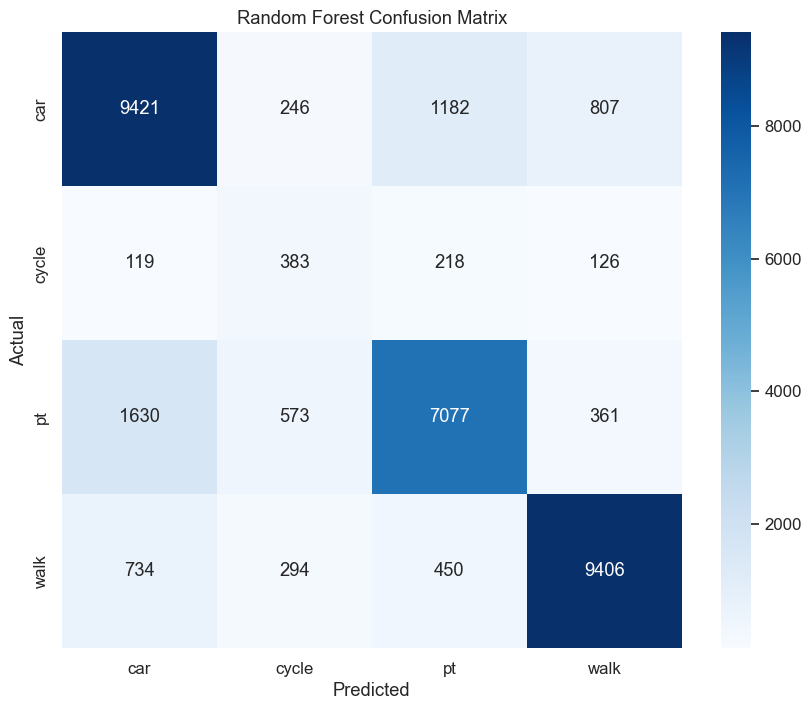

<Axes: title={'center': 'Feature Importance'}>

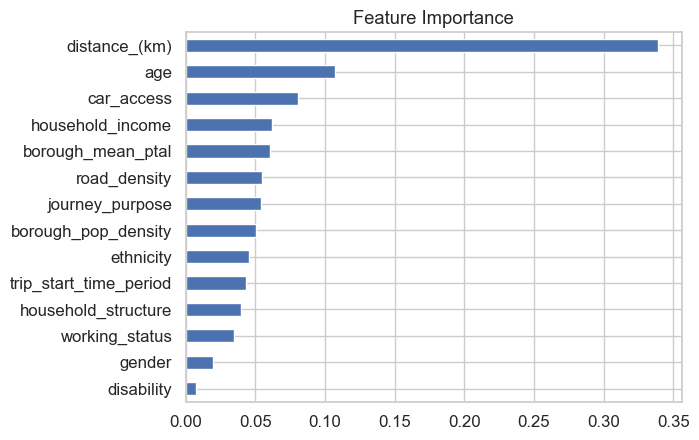

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 初始化模型
# 考虑到数据量较大，我们先用一个合理的参数，避免跑太久
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20, 
    random_state=42, 
    n_jobs=-1  # 使用所有 CPU 核心加速
)

# 2. 训练模型 (使用 SMOTE 后的 Set A)
print("正在训练随机森林模型...")
rf_model.fit(X_train_set_A, y_train_res)

# 3. 在验证集上进行预测
y_pred_rf = rf_model.predict(X_val_set_A)

# 4. 输出评估报告
print("\n--- 随机森林 (Random Forest) 验证集表现 ---")
print(f"准确率 (Accuracy): {accuracy_score(y_val_le, y_pred_rf):.4f}")
print("\n详细分类报告:")
# target_names 对应你的 mode 类别
print(classification_report(y_val_le, y_pred_rf, target_names=le_y.classes_))

# 5. 绘制混淆矩阵
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val_le, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

importances = pd.Series(rf_model.feature_importances_, index=X_train_set_A.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance')

XGBoost 基础版代码 (使用 Set A)

In [35]:
import sys
print(sys.version)

3.11.0 (v3.11.0:deaf509e8f, Oct 24 2022, 14:43:23) [Clang 13.0.0 (clang-1300.0.29.30)]


In [36]:
!python3.11 -m pip install xgboost


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


正在训练 XGBoost 模型...

--- XGBoost 验证集表现 ---
准确率 (Accuracy): 0.7152

详细分类报告:
              precision    recall  f1-score   support

         car       0.75      0.72      0.73     11656
       cycle       0.11      0.41      0.17       846
          pt       0.76      0.65      0.70      9641
        walk       0.82      0.80      0.81     10884

    accuracy                           0.72     33027
   macro avg       0.61      0.64      0.60     33027
weighted avg       0.76      0.72      0.73     33027



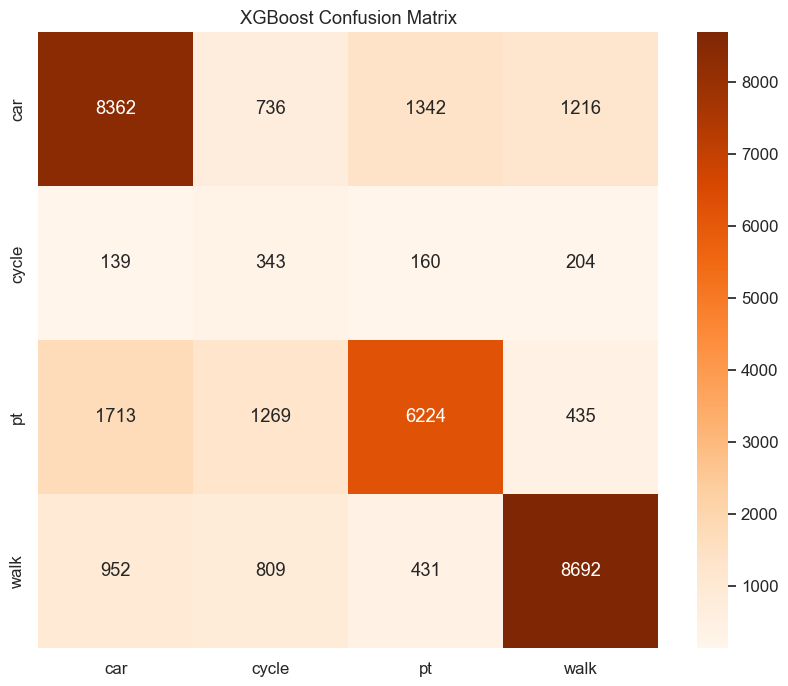

In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


# 1. 初始化模型
# 注意：XGBoost 默认处理 0, 1, 2, 3 这样的数字标签
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    tree_method='hist', # 使用直方图算法加速
    device="cpu"        # 如果你有 GPU 可以改为 "cuda"
)

# 2. 训练模型 (使用 SMOTE 后的 Set A)
print("正在训练 XGBoost 模型...")
xgb_model.fit(X_train_set_A, y_train_res)

# 3. 验证集预测
y_pred_xgb = xgb_model.predict(X_val_set_A)

# 4. 输出结果
print("\n--- XGBoost 验证集表现 ---")
print(f"准确率 (Accuracy): {accuracy_score(y_val_le, y_pred_xgb):.4f}")
print("\n详细分类报告:")
print(classification_report(y_val_le, y_pred_xgb, target_names=le_y.classes_))

# 5. 混淆矩阵
plt.figure(figsize=(10, 8))
cm_xgb = confusion_matrix(y_val_le, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.title('XGBoost Confusion Matrix')
plt.show()


构建 DNN Baseline (Set B)

In [38]:
!python3.11 -m pip install tensorflow-macos tensorflow-metal


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [39]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# 1. 确定输入维度 (Set B 应该是 51)
input_dim = X_train_set_B.shape[1]
num_classes = len(le_y.classes_)

# 2. 构建模型架构
def build_dnn_model():
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2), # 防止过拟合
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax') # 多分类输出
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

dnn_model = build_dnn_model()

# 3. 设置早停机制，防止空跑
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# 4. 开始训练
print("🚀 开始训练 DNN Baseline (One-hot 版)...")
history = dnn_model.fit(
    X_train_set_B, y_train_res, # 使用 SMOTE 平衡后的数据
    validation_data=(X_val_set_B, y_val_le),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

2026-04-20 00:25:18.119877: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-20 00:25:18.119976: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-20 00:25:18.119992: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-20 00:25:18.120034: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-20 00:25:18.120297: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


🚀 开始训练 DNN Baseline (One-hot 版)...
Epoch 1/50


2026-04-20 00:25:19.277099: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


850/850 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.4814 - loss: 1.3218 - val_accuracy: 0.5004 - val_loss: 1.1867
Epoch 2/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.3855 - loss: 2.7509 - val_accuracy: 0.2110 - val_loss: 2.4635
Epoch 3/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.3127 - loss: 8.6164 - val_accuracy: 0.2766 - val_loss: 12.8912
Epoch 4/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.2965 - loss: 10.3646 - val_accuracy: 0.3925 - val_loss: 19.7457
Epoch 5/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.2988 - loss: 9.2120 - val_accuracy: 0.1993 - val_loss: 11.4373
Epoch 6/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.3013 - loss: 7.5923 - val_accuracy: 0.3293 - val_loss: 4.6659


In [40]:
from sklearn.metrics import classification_report

y_pred_prob = dnn_model.predict(X_val_set_B)
y_pred_dnn = y_pred_prob.argmax(axis=1)

print("\n--- DNN (One-hot) 验证集表现 ---")
print(classification_report(y_val_le, y_pred_dnn, target_names=le_y.classes_))

1033/1033 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

--- DNN (One-hot) 验证集表现 ---
              precision    recall  f1-score   support

         car       0.66      0.50      0.57     11656
       cycle       0.05      0.40      0.08       846
          pt       0.57      0.72      0.64      9641
        walk       0.71      0.32      0.44     10884

    accuracy                           0.50     33027
   macro avg       0.50      0.48      0.43     33027
weighted avg       0.63      0.50      0.53     33027



dnn (Set C)

In [41]:
from tensorflow.keras.layers import Input, Embedding, Reshape, Concatenate, Dense, Dropout
from tensorflow.keras.models import Model

# --- A. 准备输入数据 (我们需要分开输入) ---
# 数值特征输入
X_train_num = X_train_res[num_features].values
X_val_num = X_val_le[num_features].values

# 分类特征输入 (每个特征需要单独的一列)
X_train_cat = [X_train_res[col].values for col in cat_features]
X_val_cat = [X_val_le[col].values for col in cat_features]

# --- B. 构建带 Embedding 的模型架构 ---
all_inputs = []
all_embeddings = []

# 1. 处理分类变量的 Embedding
for i, col in enumerate(cat_features):
    vocab_size = X_train_res[col].nunique() + 1
    # 嵌入维度的经验公式: min(50, (vocab_size + 1) // 2)
    emb_dim = min(50, (vocab_size + 1) // 2)
    
    input_cat = Input(shape=(1,), name=f"input_{col}")
    emb = Embedding(input_dim=vocab_size, output_dim=emb_dim, name=f"emb_{col}")(input_cat)
    emb = Reshape(target_shape=(emb_dim,))(emb)
    
    all_inputs.append(input_cat)
    all_embeddings.append(emb)

# 2. 处理数值变量输入
input_num = Input(shape=(len(num_features),), name="input_numerical")
all_inputs.append(input_num)
all_embeddings.append(input_num)

# 3. 拼接所有层
x = Concatenate()(all_embeddings)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dense(num_classes, activation='softmax')(x)

# 4. 编译模型
embedding_model = Model(inputs=all_inputs, outputs=x)
embedding_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# --- C. 训练模型 ---
print("🚀 正在训练 Entity Embedding 模型 (Set C)...")
history_emb = embedding_model.fit(
    X_train_cat + [num_train_sc], y_train_res,
    validation_data=(X_val_cat + [num_val_sc], y_val_le),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

🚀 正在训练 Entity Embedding 模型 (Set C)...
Epoch 1/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.5882 - loss: 1.0037 - val_accuracy: 0.6620 - val_loss: 0.9283
Epoch 2/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.5656 - loss: 1.0674 - val_accuracy: 0.4934 - val_loss: 1.1572
Epoch 3/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.5158 - loss: 1.2454 - val_accuracy: 0.6240 - val_loss: 0.9688
Epoch 4/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.4696 - loss: 1.5576 - val_accuracy: 0.4979 - val_loss: 1.7787
Epoch 5/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.4259 - loss: 2.0935 - val_accuracy: 0.4368 - val_loss: 1.9995
Epoch 6/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.3854 - loss: 3.0557 - val_accuracy: 0.4882 - val_loss: 1.4838


1033/1033 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

--- Entity Embedding 模型验证集表现 ---
              precision    recall  f1-score   support

         car       0.70      0.70      0.70     11656
       cycle       0.08      0.36      0.13       846
          pt       0.78      0.47      0.58      9641
        walk       0.76      0.82      0.79     10884

    accuracy                           0.66     33027
   macro avg       0.58      0.59      0.55     33027
weighted avg       0.73      0.66      0.68     33027



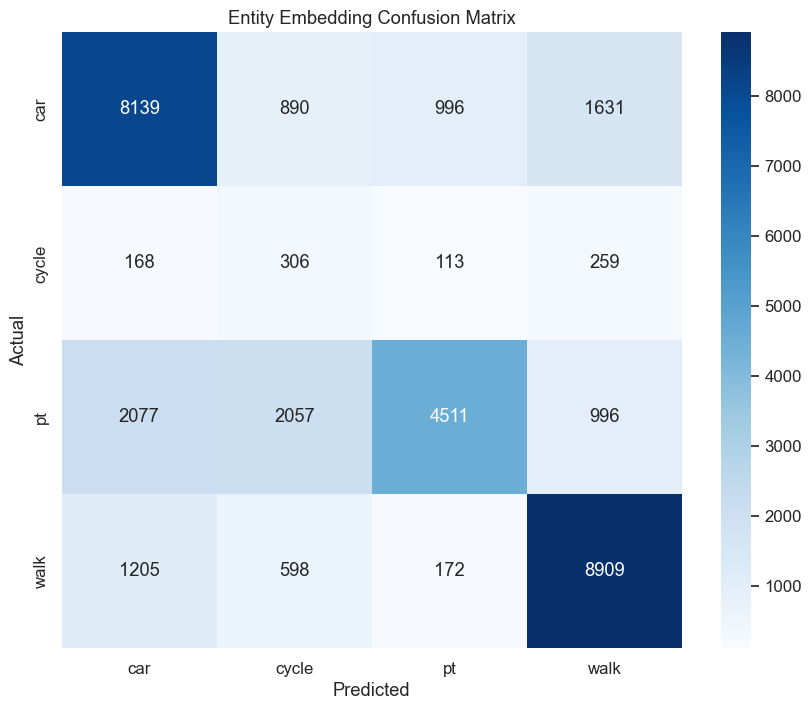

In [42]:
from sklearn.metrics import classification_report, confusion_matrix

# 注意：输入需要和训练时一致，即 分类列表 + 数值矩阵
y_pred_prob = embedding_model.predict(X_val_cat + [num_val_sc])
y_pred_emb = y_pred_prob.argmax(axis=1)

print("\n--- Entity Embedding 模型验证集表现 ---")
print(classification_report(y_val_le, y_pred_emb, target_names=le_y.classes_))

# 绘制混淆矩阵
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val_le, y_pred_emb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.title('Entity Embedding Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()